# Seasonal

A seasonal series is a repeating cycle riding on a trend — daily traffic, weekly sales, yearly demand. `SeasonalGenerator` builds one by adding a periodic wave, a linear trend, and observation noise, which makes it the natural test of whether a model captures periodicity and extrapolates the level.

::: {.callout-note}
## The model

$$y_t = \text{base} + \text{trend}\cdot t + \text{amplitude}\cdot s\!\left(2\pi t / \text{period}\right) + \varepsilon_t$$

- `seasonality_period` — length of one cycle in time steps (24 gives a daily cycle on hourly data).
- `seasonality_amplitude` — height of the seasonal swing.
- `trend` — linear drift per step; `base_level` — the starting level.
- `noise_level` — standard deviation of the additive noise.
:::

In [ ]:
import polars as pl
import matplotlib.pyplot as plt

from synforecast.generators import SeasonalGenerator

## Define generator parameters

Configure a seasonal generator with daily seasonality (24-hour period), a slight upward trend, and a base level of 50.

In [ ]:
params = {
    "min_length": 168,
    "max_length": 336,
    "freq": "h",
    "seasonality_period": 24,
    "seasonality_amplitude": 15.0,
    "trend": 0.05,
    "noise_level": 2.0,
    "base_level": 50.0,
    "seed": 123,
}

generator = SeasonalGenerator(engine="polars", **params)
df = generator.generate(n_series=3)

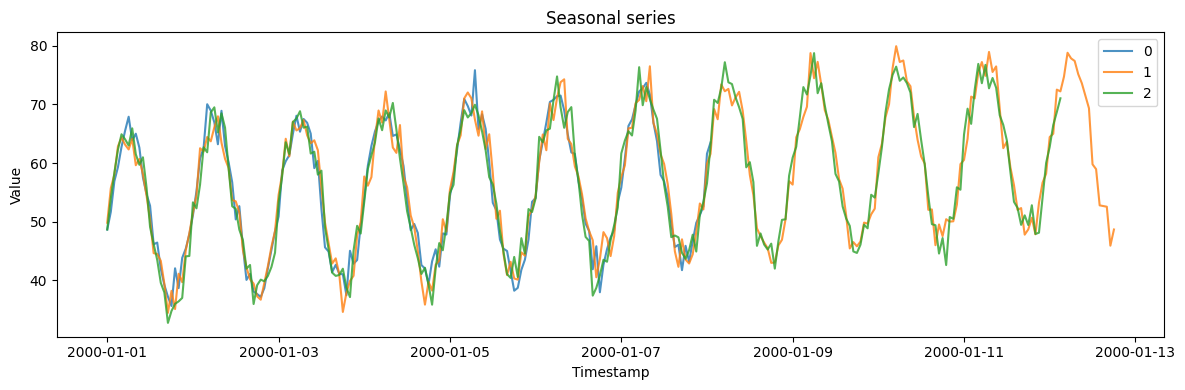

In [ ]:
fig, ax = plt.subplots(figsize=(12, 4))
for uid in df["unique_id"].unique().to_list():
    series = df.filter(pl.col("unique_id") == uid)
    ax.plot(series["ds"].to_list(), series["y"].to_list(), label=uid, alpha=0.8)
ax.set_xlabel("Timestamp")
ax.set_ylabel("Value")
ax.set_title("Seasonal series")
ax.legend()
plt.tight_layout()
plt.show()

Every series repeats on a 24-step cycle around a gently rising level. The series have different lengths (`min_length` ≠ `max_length`) but share the same daily shape and trend — the seasonal structure a forecaster should learn.

## Inspect the generated data

In [ ]:
print(f"Generated {df['unique_id'].n_unique()} time series")
print(f"Total observations: {len(df)}")
df.head(10)

Generated 3 time series
Total observations: 721


unique_id,ds,y
cat,datetime[ns],f64
"""0""",2000-01-01 00:00:00,48.634355
"""0""",2000-01-01 01:00:00,51.658968
"""0""",2000-01-01 02:00:00,56.909722
"""0""",2000-01-01 03:00:00,59.2974
"""0""",2000-01-01 04:00:00,62.751023
"""0""",2000-01-01 05:00:00,65.499531
"""0""",2000-01-01 06:00:00,67.897628
"""0""",2000-01-01 07:00:00,63.845217
"""0""",2000-01-01 08:00:00,65.0017


## Statistics by series

In [ ]:
df.group_by("unique_id").agg(
    [
        pl.col("y").count().alias("count"),
        pl.col("y").min().alias("min_value"),
        pl.col("y").max().alias("max_value"),
        pl.col("y").mean().alias("mean_value"),
        pl.col("y").std().alias("std_value"),
    ]
)

unique_id,count,min_value,max_value,mean_value,std_value
cat,u32,f64,f64,f64,f64
"""2""",268,32.718865,78.747915,56.740124,11.285512
"""0""",170,35.600282,75.837123,54.621329,10.619455
"""1""",283,34.431384,79.936749,57.388507,11.255673


## Sample of one series

View the first 24 hours of a single series to see the seasonal pattern.

In [ ]:
df.filter(pl.col("unique_id") == "0").head(24)

unique_id,ds,y
cat,datetime[ns],f64
"""0""",2000-01-01 00:00:00,48.634355
"""0""",2000-01-01 01:00:00,51.658968
"""0""",2000-01-01 02:00:00,56.909722
"""0""",2000-01-01 03:00:00,59.2974
"""0""",2000-01-01 04:00:00,62.751023
…,…,…
"""0""",2000-01-01 19:00:00,42.030839
"""0""",2000-01-01 20:00:00,38.652835
"""0""",2000-01-01 21:00:00,43.811501


::: {.callout-tip}
## Related generators

- [SARIMA](sarima) — seasonality with autoregressive/moving-average dynamics instead of a fixed wave.
- [ETS](ets) — seasonality through exponential-smoothing state-space models.
- Layer on [anomalies](../../capabilities/anomalies) or [changepoints](../../capabilities/changepoints) to stress-test a seasonal model.
:::